In [1]:
# --- 必要なら最初に: pipでpandasを入れる ---
# !pip install pandas

import pandas as pd
from pathlib import Path
import re

# ===== 設定 =====
base_dir = Path(r"E:\refit\h2o_2\out_prof_ch4")  # 入力フォルダ
out_path = Path(r"E:\refit\CH4.csv")             # 出力ファイル

# 末尾が scan.csv のうち、ch_h2ostr_<value>_scan.csv にマッチするものだけ使う
# 例: ch_h2ostr_0.00_scan.csv -> 列名 "0.00"
pat = re.compile(r"^ch_h2ostr_([-+]?\d+(?:\.\d+)?)_scan\.csv$", re.IGNORECASE)

def read_wave_rad_series(csv_path: Path):
    """
    CSVを読み、1列目(=波長)と10列目(=rad)を数値としてSeriesにして返す。
    Index: 波長, Values: rad
    ヘッダ行/文字列行が混ざっても自動的に除去します。
    区切り文字は自動判別します。
    """
    # 文字コードはUTF-8/CP932あたりを試行
    last_err = None
    for enc in ("utf-8-sig", "cp932", "utf-8"):
        try:
            df = pd.read_csv(csv_path, sep=None, engine="python",
                             header=None, comment="#", encoding=enc)
            break
        except Exception as e:
            last_err = e
            df = None
    if df is None:
        raise RuntimeError(f"読込失敗: {csv_path}\n{last_err}")

    # 最低限10列あることをチェック
    if df.shape[1] < 10:
        raise ValueError(f"列数が不足しています(必要≥10, 実際={df.shape[1]}): {csv_path}")

    # 数値化（数値でない行は落とす）
    wv = pd.to_numeric(df.iloc[:, 0], errors="coerce")   # 1列目: 波長
    rad = pd.to_numeric(df.iloc[:, 9], errors="coerce")  # 10列目: rad
    mask = wv.notna() & rad.notna()
    s = pd.Series(rad[mask].to_numpy(), index=wv[mask].to_numpy())
    # 波長で昇順ソート
    s = s.sort_index()
    return s

# 対象ファイルの走査
candidates = []
for p in base_dir.glob("*scan.csv"):  # 再帰にしたいなら "**/*scan.csv" に変更
    m = pat.match(p.name)
    if m:
        conc_str = m.group(1)       # 例: "0.00"
        conc_val = float(conc_str)  # 並び替え用
        candidates.append((conc_val, f"{conc_val:.2f}", p))

if not candidates:
    raise FileNotFoundError(f"対象ファイルが見つかりませんでした: {base_dir} 内の *scan.csv")

# 濃度で昇順に
candidates.sort(key=lambda x: x[0])

# 各CSVから Series を作成（Index=波長, Values=rad）
series_by_conc = {}
for conc_val, conc_label, path in candidates:
    s = read_wave_rad_series(path)
    series_by_conc[conc_label] = s

# 波長で内部結合（全ファイルに共通する波長だけを採用）
# もし全波長を残して欠損を許容したいなら join="outer" に変更可
df = pd.concat(series_by_conc.values(), axis=1, join="inner")
df.columns = list(series_by_conc.keys())
df.index.name = "wavelength"

# 出力フォルダが無ければ作成
out_path.parent.mkdir(parents=True, exist_ok=True)

# 保存（指数表記を避けたい/桁を揃えたい場合は float_format を調整）
df.to_csv(out_path, encoding="utf-8-sig", float_format="%.10g")

print(f"書き出し完了: {out_path}")
print(f"形状: {df.shape[0]} 行 × {df.shape[1]+1} 列（波長列を含む）")
display(df.head())


RuntimeError: 読込失敗: E:\refit\h2o_2\out_prof_ch4\ch_h2ostr_0.00_scan.csv
Expected 5 fields in line 5, saw 35

In [2]:
# !pip install pandas  # 必要なら有効化

import pandas as pd
from pathlib import Path
import re
import io

# ===== 設定 =====
base_dir = Path(r"E:\refit\h2o_2\out_prof_ch4")  # 入力フォルダ
out_path = Path(r"E:\refit\CH4.csv")             # 出力先

# ch_h2ostr_<濃度>_scan.csv のみ対象（末尾が scan.csv）
pat = re.compile(r"^ch_h2ostr_([-+]?\d+(?:\.\d+)?)_scan\.csv$", re.IGNORECASE)

def read_wave_rad_series(csv_path: Path):
    """
    ファイルから 1列目(波長)と 10列目(rad) を抽出して Series を返す。
    - 2行ヘッダ（'Waveln,...' と '[nm],...'）を検出してスキップ
    - 区切りは ','（コンマ）
    - Index: 波長（数値）, Values: rad（数値）
    """
    # 文字コードは順に試行
    text = None
    last_err = None
    for enc in ("utf-8-sig", "cp932", "utf-8"):
        try:
            text = csv_path.read_text(encoding=enc, errors="ignore")
            break
        except Exception as e:
            last_err = e
    if text is None:
        raise RuntimeError(f"読込失敗: {csv_path}\n{last_err}")

    lines = text.splitlines()

    # 'Waveln' 行（上段ヘッダ）を探す
    header_idx = None
    for i, line in enumerate(lines[:100]):
        if "Waveln" in line:
            header_idx = i
            break

    # データ本体の行だけを組み立て
    data_lines = []
    if header_idx is not None:
        # ヘッダ2行の直後から
        candidate = lines[header_idx + 2 :]
    else:
        # ヘッダが見つからない場合は先頭から
        candidate = lines

    # 数値で始まる行のみ採用（ゴミ行/終端括弧などを除去）
    num_pat = re.compile(r"\s*-?\d+(?:\.\d+)?\s*,")
    for ln in candidate:
        if num_pat.match(ln):
            data_lines.append(ln)

    if not data_lines:
        raise RuntimeError(f"データ行が見つかりません: {csv_path}")

    # CSVとして読み込み（コンマ区切り、ヘッダなし）
    df = pd.read_csv(io.StringIO("\n".join(data_lines)), sep=",", header=None, engine="python")

    # 1始まりで10列目(= index 9) が存在するか確認
    if df.shape[1] < 10:
        raise ValueError(f"列数が不足しています(必要≥10, 実際={df.shape[1]}): {csv_path}")

    # 数値化
    wv = pd.to_numeric(df.iloc[:, 0], errors="coerce")   # 1列目: 波長
    rad = pd.to_numeric(df.iloc[:, 9], errors="coerce")  # 10列目: rad

    # 欠損を除外し、波長でソート
    mask = wv.notna() & rad.notna()
    s = pd.Series(rad[mask].to_numpy(), index=wv[mask].to_numpy()).sort_index()
    return s

# 対象ファイル収集
candidates = []
for p in base_dir.glob("*scan.csv"):  # サブフォルダも含めるなら "**/*scan.csv"
    m = pat.match(p.name)
    if m:
        conc_val = float(m.group(1))
        conc_label = f"{conc_val:.2f}"  # 列名は小数2桁で統一
        candidates.append((conc_val, conc_label, p))

if not candidates:
    raise FileNotFoundError(f"対象ファイルが見つかりませんでした: {base_dir} 内の *scan.csv")

# 濃度で昇順
candidates.sort(key=lambda x: x[0])

# 各CSV -> Series(Index=波長, Values=rad)
series_by_conc = {}
for conc_val, conc_label, path in candidates:
    s = read_wave_rad_series(path)
    series_by_conc[conc_label] = s
    print(f"読込OK: {path.name} -> {conc_label} ({len(s)}行)")

# 波長で内部結合（共通の波長のみ採用）
# すべての波長を残して欠損を許容したい場合は join="outer" に変更可
df = pd.concat(series_by_conc.values(), axis=1, join="inner")
df.columns = list(series_by_conc.keys())
df.index.name = "wavelength"

# 出力先フォルダを作成して保存
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path, encoding="utf-8-sig", float_format="%.10g")

print(f"\n書き出し完了: {out_path}")
print(f"形状: {df.shape[0]} 行 × {df.shape[1]+1} 列（波長列を含む）")
display(df.head())


読込OK: ch_h2ostr_0.00_scan.csv -> 0.00 (2121行)
読込OK: ch_h2ostr_0.10_scan.csv -> 0.10 (2121行)
読込OK: ch_h2ostr_0.20_scan.csv -> 0.20 (2121行)
読込OK: ch_h2ostr_0.30_scan.csv -> 0.30 (2121行)
読込OK: ch_h2ostr_0.40_scan.csv -> 0.40 (2121行)
読込OK: ch_h2ostr_0.50_scan.csv -> 0.50 (2121行)
読込OK: ch_h2ostr_0.60_scan.csv -> 0.60 (2121行)
読込OK: ch_h2ostr_0.70_scan.csv -> 0.70 (2121行)
読込OK: ch_h2ostr_0.80_scan.csv -> 0.80 (2121行)
読込OK: ch_h2ostr_0.90_scan.csv -> 0.90 (2121行)
読込OK: ch_h2ostr_1.00_scan.csv -> 1.00 (2121行)
読込OK: ch_h2ostr_1.10_scan.csv -> 1.10 (2121行)
読込OK: ch_h2ostr_1.20_scan.csv -> 1.20 (2121行)
読込OK: ch_h2ostr_1.30_scan.csv -> 1.30 (2121行)
読込OK: ch_h2ostr_1.40_scan.csv -> 1.40 (2121行)
読込OK: ch_h2ostr_1.50_scan.csv -> 1.50 (2121行)
読込OK: ch_h2ostr_1.60_scan.csv -> 1.60 (2121行)
読込OK: ch_h2ostr_1.70_scan.csv -> 1.70 (2121行)
読込OK: ch_h2ostr_1.80_scan.csv -> 1.80 (2121行)
読込OK: ch_h2ostr_1.90_scan.csv -> 1.90 (2121行)
読込OK: ch_h2ostr_2.00_scan.csv -> 2.00 (2121行)
読込OK: ch_h2ostr_2.10_scan.csv -> 2

,0.00,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,...,4.10,4.20,4.30,4.40,4.50,4.60,4.70,4.80,4.90,5.00
wavelength,,,,,,,,,,,,,,,,,,,,,
380,3.97691,3.97691,3.97691,3.97691,3.97691,3.97691,3.97691,3.97691,3.97691,3.97691,...,3.97692,3.97692,3.97692,3.97692,3.97692,3.97692,3.97692,3.97692,3.97692,3.97693
381,4.67327,4.67327,4.67327,4.67327,4.67327,4.67327,4.67327,4.67327,4.67327,4.67327,...,4.67328,4.67328,4.67328,4.67328,4.67328,4.67328,4.67328,4.67328,4.67328,4.67328
382,3.82361,3.82361,3.82361,3.82361,3.82361,3.82361,3.82361,3.82361,3.82361,3.82361,...,3.82362,3.82362,3.82362,3.82362,3.82362,3.82362,3.82362,3.82362,3.82362,3.82363
383,3.14014,3.14014,3.14014,3.14014,3.14014,3.14014,3.14014,3.14014,3.14014,3.14014,...,3.14015,3.14015,3.14015,3.14015,3.14015,3.14015,3.14015,3.14015,3.14015,3.14015
384,2.93575,2.93575,2.93575,2.93575,2.93575,2.93575,2.93575,2.93575,2.93575,2.93575,...,2.93576,2.93576,2.93576,2.93576,2.93576,2.93576,2.93576,2.93576,2.93576,2.93576


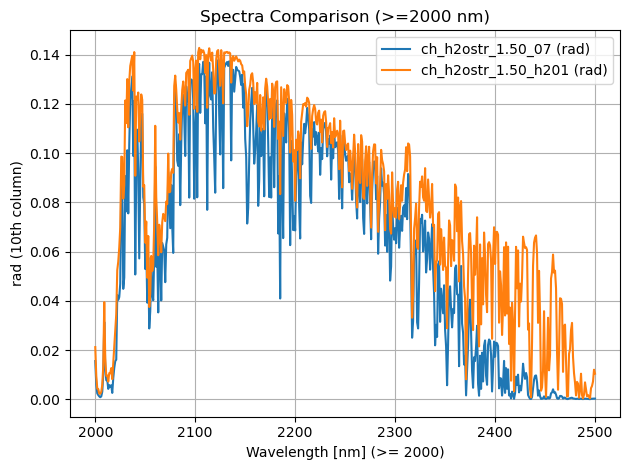

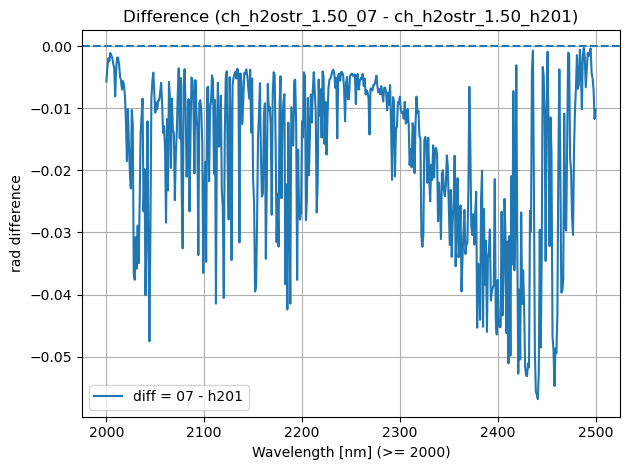

ModuleNotFoundError: No module named 'caas_jupyter_tools'

In [3]:
# Comparison of two CH4 scan CSVs as requested.
# This cell will:
# 1) Robustly read the two CSVs, extracting column 1 (wavelength) and column 10 (rad).
# 2) Filter to wavelengths >= 2000 nm.
# 3) Plot both series and their difference (07 - h201).
# 4) Save a CSV of the aligned data and difference for download.
#
# It will try Windows paths first (as per your environment), and if not found, it will fall back
# to the uploaded files in /mnt/data for this notebook environment.
#
# Notes:
# - If your two files have slightly different wavelength grids, we take the intersection (inner join).
#   If you prefer interpolation instead, we can adjust to interpolate one onto the other.
# - No seaborn, single-figure-per-chart, and no explicit colors, per the plotting constraints.

import pandas as pd
from pathlib import Path
import re
import io
import matplotlib.pyplot as plt

# --------- Configure paths ---------
win_path_07   = Path(r"E:\refit\h2o_2\ch_h2ostr_1.50_07_scan.csv")
win_path_h201 = Path(r"E:\refit\h2o_2\ch_h2ostr_1.50_h201_scan.csv")

nb_path_07    = Path("/mnt/data/ch_h2ostr_1.50_07_scan.csv")
nb_path_h201  = Path("/mnt/data/ch_h2ostr_1.50_h201_scan.csv")

# choose actual paths to use
if win_path_07.exists() and win_path_h201.exists():
    path_07, path_h201 = win_path_07, win_path_h201
    out_dir = Path(r"E:\refit\h2o_2")
else:
    # fallback to notebook-uploaded files
    path_07, path_h201 = nb_path_07, nb_path_h201
    out_dir = Path("/mnt/data")

# --------- Robust CSV reader focusing on 1st and 10th columns ---------
def read_wave_rad_series(csv_path: Path):
    """
    Read a CSV that may contain a 2-line header (e.g., 'Waveln,...' then '[nm],...').
    Extract the 1st column (wavelength) and 10th column (rad), return as a Series:
      index = wavelength (numeric), values = rad (numeric).
    We'll filter lines to those that begin with a number to avoid header/footer issues.
    """
    # Try common encodings
    text = None
    last_err = None
    for enc in ("utf-8-sig", "cp932", "utf-8"):
        try:
            text = csv_path.read_text(encoding=enc, errors="ignore")
            break
        except Exception as e:
            last_err = e
    if text is None:
        raise RuntimeError(f"読込失敗: {csv_path}\n{last_err}")

    lines = text.splitlines()

    # Detect the 'Waveln' header line if present
    header_idx = None
    for i, line in enumerate(lines[:100]):
        if "Waveln" in line:
            header_idx = i
            break

    # Start from 2 lines after the 'Waveln' header; else from beginning
    candidate = lines[header_idx + 2 :] if header_idx is not None else lines

    # Keep only numeric-leading lines (to avoid stray headers/footers)
    # Accept both comma- and whitespace-separated possibilities by allowing optional spaces then number
    num_leading = re.compile(r"^\s*[-+]?\d+(?:\.\d+)?\s*[, \t]")
    data_lines = [ln for ln in candidate if num_leading.match(ln)]

    if not data_lines:
        raise RuntimeError(f"データ行が見つかりません: {csv_path}")

    # Read with automatic delimiter detection (python engine)
    df = pd.read_csv(io.StringIO("\n".join(data_lines)), sep=None, engine="python", header=None)

    if df.shape[1] < 10:
        raise ValueError(f"列数が不足しています(必要≥10, 実際={df.shape[1]}): {csv_path}")

    wv  = pd.to_numeric(df.iloc[:, 0], errors="coerce")   # 1st column: wavelength
    rad = pd.to_numeric(df.iloc[:, 9], errors="coerce")   # 10th column: rad
    mask = wv.notna() & rad.notna()
    s = pd.Series(rad[mask].to_numpy(), index=wv[mask].to_numpy()).sort_index()
    return s

# --------- Read both files ---------
s_07   = read_wave_rad_series(path_07)
s_h201 = read_wave_rad_series(path_h201)

# --------- Filter to wavelength >= 2000 nm ---------
s_07_f   = s_07[s_07.index >= 2000]
s_h201_f = s_h201[s_h201.index >= 2000]

# Align on common wavelengths (inner join)
common_wv = s_07_f.index.intersection(s_h201_f.index)
s_07_c    = s_07_f.loc[common_wv]
s_h201_c  = s_h201_f.loc[common_wv]

# Difference (07 - h201)
diff = s_07_c - s_h201_c

# --------- Build a DataFrame for export ---------
df_out = pd.DataFrame({
    "wavelength_nm": common_wv,
    "rad_07": s_07_c.values,
    "rad_h201": s_h201_c.values,
    "diff_07_minus_h201": diff.values,
})

# Save CSV for download (in the active out_dir)
out_csv = out_dir / "CH4_diff_1.50_07_minus_h201.csv"
df_out.to_csv(out_csv, index=False, encoding="utf-8-sig", float_format="%.10g")

# --------- Plot 1: both spectra (>= 2000 nm) ---------
plt.figure()
plt.plot(s_07_c.index, s_07_c.values, label="ch_h2ostr_1.50_07 (rad)")
plt.plot(s_h201_c.index, s_h201_c.values, label="ch_h2ostr_1.50_h201 (rad)")
plt.xlabel("Wavelength [nm] (>= 2000)")
plt.ylabel("rad (10th column)")
plt.title("Spectra Comparison (>=2000 nm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --------- Plot 2: difference (07 - h201) ---------
plt.figure()
plt.plot(common_wv, diff.values, label="diff = 07 - h201")
plt.axhline(0, linestyle="--")
plt.xlabel("Wavelength [nm] (>= 2000)")
plt.ylabel("rad difference")
plt.title("Difference (ch_h2ostr_1.50_07 - ch_h2ostr_1.50_h201)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Also display a small preview of the data
from caas_jupyter_tools import display_dataframe_to_user
display_dataframe_to_user(name="CH4 difference (>=2000 nm)", dataframe=df_out)

print(f"差分は (07 - h201) として計算しました。")
print(f"データの保存先: {out_csv}")


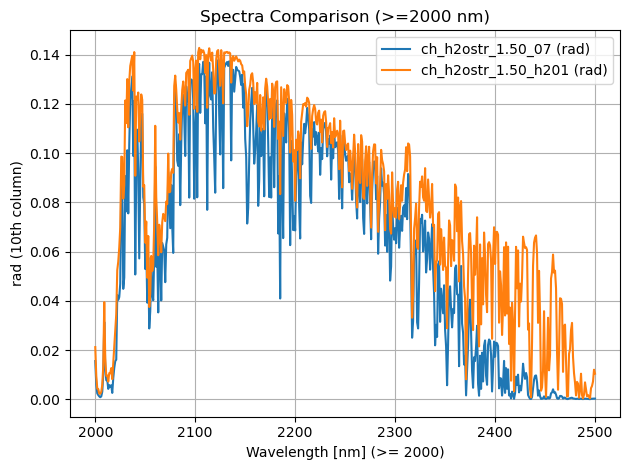

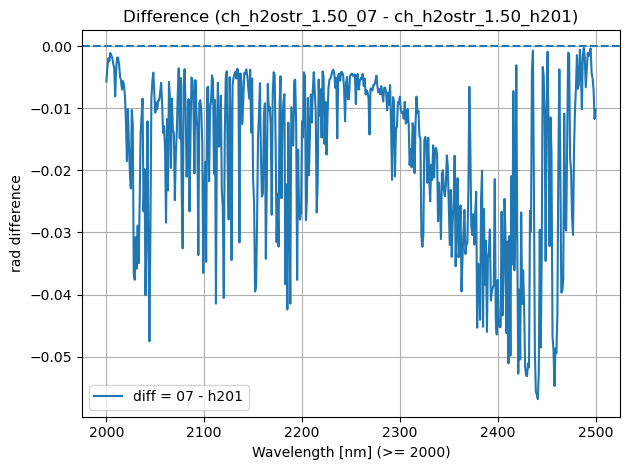

ModuleNotFoundError: No module named 'caas_jupyter_tools'

In [4]:
# Comparison of two CH4 scan CSVs as requested.
# This cell will:
# 1) Robustly read the two CSVs, extracting column 1 (wavelength) and column 10 (rad).
# 2) Filter to wavelengths >= 2000 nm.
# 3) Plot both series and their difference (07 - h201).
# 4) Save a CSV of the aligned data and difference for download.
#
# It will try Windows paths first (as per your environment), and if not found, it will fall back
# to the uploaded files in /mnt/data for this notebook environment.
#
# Notes:
# - If your two files have slightly different wavelength grids, we take the intersection (inner join).
#   If you prefer interpolation instead, we can adjust to interpolate one onto the other.
# - No seaborn, single-figure-per-chart, and no explicit colors, per the plotting constraints.

import pandas as pd
from pathlib import Path
import re
import io
import matplotlib.pyplot as plt

# --------- Configure paths ---------
win_path_07   = Path(r"E:\refit\h2o_2\ch_h2ostr_1.50_07_scan.csv")
win_path_h201 = Path(r"E:\refit\h2o_2\ch_h2ostr_1.50_h201_scan.csv")

nb_path_07    = Path("/mnt/data/ch_h2ostr_1.50_07_scan.csv")
nb_path_h201  = Path("/mnt/data/ch_h2ostr_1.50_h201_scan.csv")

# choose actual paths to use
if win_path_07.exists() and win_path_h201.exists():
    path_07, path_h201 = win_path_07, win_path_h201
    out_dir = Path(r"E:\refit\h2o_2")
else:
    # fallback to notebook-uploaded files
    path_07, path_h201 = nb_path_07, nb_path_h201
    out_dir = Path("/mnt/data")

# --------- Robust CSV reader focusing on 1st and 10th columns ---------
def read_wave_rad_series(csv_path: Path):
    """
    Read a CSV that may contain a 2-line header (e.g., 'Waveln,...' then '[nm],...').
    Extract the 1st column (wavelength) and 10th column (rad), return as a Series:
      index = wavelength (numeric), values = rad (numeric).
    We'll filter lines to those that begin with a number to avoid header/footer issues.
    """
    # Try common encodings
    text = None
    last_err = None
    for enc in ("utf-8-sig", "cp932", "utf-8"):
        try:
            text = csv_path.read_text(encoding=enc, errors="ignore")
            break
        except Exception as e:
            last_err = e
    if text is None:
        raise RuntimeError(f"読込失敗: {csv_path}\n{last_err}")

    lines = text.splitlines()

    # Detect the 'Waveln' header line if present
    header_idx = None
    for i, line in enumerate(lines[:100]):
        if "Waveln" in line:
            header_idx = i
            break

    # Start from 2 lines after the 'Waveln' header; else from beginning
    candidate = lines[header_idx + 2 :] if header_idx is not None else lines

    # Keep only numeric-leading lines (to avoid stray headers/footers)
    # Accept both comma- and whitespace-separated possibilities by allowing optional spaces then number
    num_leading = re.compile(r"^\s*[-+]?\d+(?:\.\d+)?\s*[, \t]")
    data_lines = [ln for ln in candidate if num_leading.match(ln)]

    if not data_lines:
        raise RuntimeError(f"データ行が見つかりません: {csv_path}")

    # Read with automatic delimiter detection (python engine)
    df = pd.read_csv(io.StringIO("\n".join(data_lines)), sep=None, engine="python", header=None)

    if df.shape[1] < 10:
        raise ValueError(f"列数が不足しています(必要≥10, 実際={df.shape[1]}): {csv_path}")

    wv  = pd.to_numeric(df.iloc[:, 0], errors="coerce")   # 1st column: wavelength
    rad = pd.to_numeric(df.iloc[:, 9], errors="coerce")   # 10th column: rad
    mask = wv.notna() & rad.notna()
    s = pd.Series(rad[mask].to_numpy(), index=wv[mask].to_numpy()).sort_index()
    return s

# --------- Read both files ---------
s_07   = read_wave_rad_series(path_07)
s_h201 = read_wave_rad_series(path_h201)

# --------- Filter to wavelength >= 2000 nm ---------
s_07_f   = s_07[s_07.index >= 2000]
s_h201_f = s_h201[s_h201.index >= 2000]

# Align on common wavelengths (inner join)
common_wv = s_07_f.index.intersection(s_h201_f.index)
s_07_c    = s_07_f.loc[common_wv]
s_h201_c  = s_h201_f.loc[common_wv]

# Difference (07 - h201)
diff = s_07_c - s_h201_c

# --------- Build a DataFrame for export ---------
df_out = pd.DataFrame({
    "wavelength_nm": common_wv,
    "rad_07": s_07_c.values,
    "rad_h201": s_h201_c.values,
    "diff_07_minus_h201": diff.values,
})

# Save CSV for download (in the active out_dir)
out_csv = out_dir / "CH4_diff_1.50_07_minus_h201.csv"
df_out.to_csv(out_csv, index=False, encoding="utf-8-sig", float_format="%.10g")

# --------- Plot 1: both spectra (>= 2000 nm) ---------
plt.figure()
plt.plot(s_07_c.index, s_07_c.values, label="ch_h2ostr_1.50_07 (rad)")
plt.plot(s_h201_c.index, s_h201_c.values, label="ch_h2ostr_1.50_h201 (rad)")
plt.xlabel("Wavelength [nm] (>= 2000)")
plt.ylabel("rad (10th column)")
plt.title("Spectra Comparison (>=2000 nm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --------- Plot 2: difference (07 - h201) ---------
plt.figure()
plt.plot(common_wv, diff.values, label="diff = 07 - h201")
plt.axhline(0, linestyle="--")
plt.xlabel("Wavelength [nm] (>= 2000)")
plt.ylabel("rad difference")
plt.title("Difference (ch_h2ostr_1.50_07 - ch_h2ostr_1.50_h201)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Also display a small preview of the data
from caas_jupyter_tools import display_dataframe_to_user
display_dataframe_to_user(name="CH4 difference (>=2000 nm)", dataframe=df_out)

print(f"差分は (07 - h201) として計算しました。")
print(f"データの保存先: {out_csv}")
